
# Sensors and Signal Analysis 2026
Author: Nuno Azevedo Silva and Catarina Monteiro

### Hands-on activity 2

This notebook supports the second Hands-on activity where the students will determine the transfer function and calibrate a real-world sensor. 

For this we will utilize:

---

**Ultrasonic Distance Sensor**:

<img src="figs/principle.png" width="600"/>

An ultrasonic distance sensor works by emitting a high-frequency sound wave and measuring the time it takes for the echo to bounce back from an object. Using a microcontroller you send the sound pulse by sending a eletric pulse to the trigger, which then waits for an echo to determine the time delay $\Delta t$. The distance can be easily calculated as 

 $\delta =\frac{\Delta t}{2}  \times c_s$ 
 
where $c_s \approx 343 m/s $ is the speed of sound.


The sensor will be connected to an Arduino that has been pre-programmed accordingly (code given in microcontroller folder).

***Experimental Setup***

Connect the circuit as shown below:

<img src="figs/setup.png" width="600"/>

## Auxiliary functions to read data

In [ ]:
import serial
import time
import numpy as np
import matplotlib.pyplot as plt

def open_serial(port, baud):
    ser = serial.Serial(port, baud, timeout=1)
    time.sleep(2)
    return ser

def read_data(ser, num_readings):

    readings = []

    for i in range(num_readings):
        line = ser.readline().decode(errors="ignore").strip()
        if line:
            readings.append(float(line))
        time.sleep(0.5)

    return np.array(readings)

def close_serial(ser):
    ser.close()

def remove_outliers(data, nreads_final=None, k=1):
    data = np.asarray(data, dtype=float)

    if data.size == 0:
        raise ValueError("Empty data")

    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1

    if iqr == 0:
        cleaned = data
    else:
        low = q1 - k * iqr
        high = q3 + k * iqr
        cleaned = data[(data >= low) & (data <= high)]

    cleaned = cleaned.tolist()

    if nreads_final is None:
        return cleaned

    if len(cleaned) < nreads_final:
        print("Not enough data points after outlier removal")
        return cleaned

    return cleaned[:nreads_final]
    
    


### Example usage

In [117]:
#Open Serial Port
port = "COM10" #Change this to match your port
baudrate = 9600
ser = open_serial(port, baudrate)  

In [123]:
#Read data
n_points = 30
data = read_data(ser, n_points)

Text(0, 0.5, 'Sensor output')

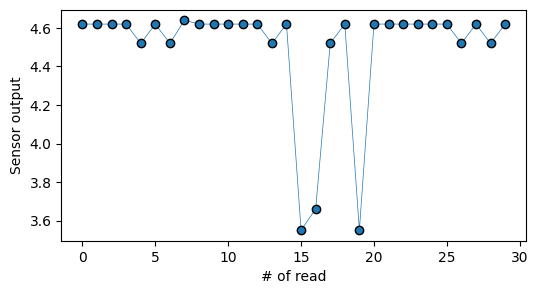

In [124]:
#Plot data
fig,ax = plt.subplots(figsize=[6,3])
ax.plot(data, lw=0.5, marker='o',markeredgecolor='k')
ax.set_xlabel("# of read")
ax.set_ylabel('Sensor output')

Text(0, 0.5, 'Sensor output')

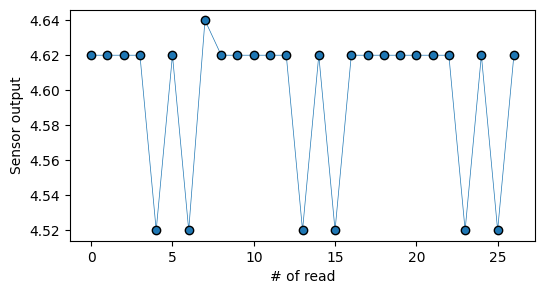

In [125]:
#Clean outliers
clean_data = remove_outliers(data)
fig,ax = plt.subplots(figsize=[6,3])
ax.plot(clean_data, lw=0.5, marker='o',markeredgecolor='k')
ax.set_xlabel("# of read")
ax.set_ylabel('Sensor output')

# 1. Acquire the data

In [3]:
#list to store the stimuli and sensor data for each stimulus
stimulus_list = []
sensor_data = []

Text(0, 0.5, 'Sensor output ($\\mu s$)')

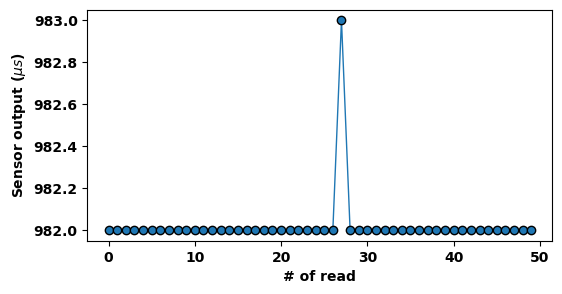

In [6]:
# modify to include data
stimulus = 75

#number of sensor reads to store
number_reads = 50

#initialize the communication with Arduino (COM3 is the port, may need to change)
ser = serial.Serial('COM3', 9600, timeout=1)
time.sleep(2)  # Give the connection a moment to initialize

data = read_data(ser, number_reads)

ser.close()

#make an histogram to accept or not the data
fig,ax = plt.subplots(figsize=[6,3])
ax.plot(data, lw=1,marker='o',markeredgecolor='k')
ax.set_xlabel("# of read")
ax.set_ylabel('Sensor output ($\mu s$)') #or arb.un. for water sensor
#accept data Y / reject data N

In [7]:
stimulus_list.append(stimulus)
sensor_data.append(data)

In [8]:
np.array(sensor_data).shape

(2, 50)

In [9]:
np.array(stimulus_list)

array([55, 75])

In [83]:
stimulus = np.savetxt('data//stimulusA.txt',np.array(stimulus_list))
data_sensorA = np.savetxt('data//data_sensorA.txt',np.array(sensor_data))

# 2. Data Analysis

Using what you have previously explored in the Jupyter notebook activity try to calibrate your sensor.
1. Start by analyzing what should be your estimator;
2. Decide on the method to compute the uncertainty;
3. Compute the transfer function and characterize your sensor;

In [84]:
stimulus = np.loadtxt('data//stimulusA.txt')
data_sensorA = np.loadtxt('data//data_sensorA.txt')